In [1]:
# Project setup
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)


Project root: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle
Processed directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed
Models directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\models


In [2]:
# Load the cleaned dataset created by data_understanding.ipynb
clean_df_path = PROCESSED_DIR / "clean_df.pkl"

if not clean_df_path.exists():
    raise FileNotFoundError(
        f"{clean_df_path} was not found. Run data_understanding.ipynb first."
    )

clean_df = pd.read_pickle(clean_df_path)

print("Cleaned dataset loaded successfully.")
print("Shape:", clean_df.shape)
print("Unique customers:", clean_df["Customer_ID"].nunique())


Cleaned dataset loaded successfully.
Shape: (100000, 36)
Unique customers: 12500


## 2. Customer-Level Train/Validation/Test Split

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
customer_target = (
    clean_df.groupby("Customer_ID")["Credit_Score"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

In [5]:
customer_target.head()

,Customer_ID,Credit_Score
0,CUS_0x1000,Poor
1,CUS_0x1009,Standard
2,CUS_0x100b,Poor
3,CUS_0x1011,Standard
4,CUS_0x1013,Standard


In [6]:
train_customers, temp_customers = train_test_split(
    customer_target,
    test_size=0.30,
    random_state=42,
    stratify=customer_target["Credit_Score"]
)

In [7]:
print("Training customers:", len(train_customers))
print("Temporary customers:", len(temp_customers))

Training customers: 8750
Temporary customers: 3750


In [8]:
val_customers, test_customers = train_test_split(
    temp_customers,
    test_size=0.50,
    random_state=42,
    stratify=temp_customers["Credit_Score"]
)

In [9]:
print("Training customers:", len(train_customers))
print("Validation customers:", len(val_customers))
print("Test customers:", len(test_customers))

Training customers: 8750
Validation customers: 1875
Test customers: 1875


In [10]:
# Convert these into customer IDs
train_ids = set(train_customers["Customer_ID"])
val_ids = set(val_customers["Customer_ID"])
test_ids = set(test_customers["Customer_ID"])

In [11]:
# Create the Actual datasets
train_df = clean_df[clean_df["Customer_ID"].isin(train_ids)].copy()

val_df = clean_df[clean_df["Customer_ID"].isin(val_ids)].copy()

test_df = clean_df[clean_df["Customer_ID"].isin(test_ids)].copy()

In [12]:
# Verify the splits
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

Train rows: 70000
Validation rows: 15000
Test rows: 15000


In [13]:
print(
    "Train/Validation overlap:",
    len(train_ids & val_ids)
)

print(
    "Train/Test overlap:",
    len(train_ids & test_ids)
)

print(
    "Validation/Test overlap:",
    len(val_ids & test_ids)
)

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


In [14]:
# Verify that each customer still has 8 observations
print(train_df["Customer_ID"].value_counts().value_counts())
print(val_df["Customer_ID"].value_counts().value_counts())
print(test_df["Customer_ID"].value_counts().value_counts())

8    8750
Name: Customer_ID, dtype: int64
8    1875
Name: Customer_ID, dtype: int64
8    1875
Name: Customer_ID, dtype: int64


In [15]:
# verify Target distribution
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print(
        data["Credit_Score"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Train
Standard    53.18
Poor        29.00
Good        17.82
Name: Credit_Score, dtype: float64

Validation
Standard    53.36
Poor        28.72
Good        17.92
Name: Credit_Score, dtype: float64

Test
Standard    52.98
Poor        29.25
Good        17.77
Name: Credit_Score, dtype: float64


## Leakage-safe Preprocessing Pipeline

In [16]:
DROP_COLUMNS = ["ID", "Customer_ID", "Name", "SSN"]

In [17]:
NUMERIC_FEATURES = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Credit_History_Months",
    "Num_Loan_Types",
    "Has_auto_loan",
    "Has_credit_builder_loan",
    "Has_personal_loan",
    "Has_home_equity_loan",
    "Has_mortgage_loan",
    "Has_student_loan",
    "Has_debt_consolidation_loan",
    "Has_payday_loan",
]

In [18]:
CATEGORICAL_FEATURES = [
    "Month",
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
]

In [19]:
TARGET = "Credit_Score"

X_train = train_df.drop(columns=[TARGET] + DROP_COLUMNS)

y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET] + DROP_COLUMNS)

y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET] + DROP_COLUMNS)

y_test = test_df[TARGET]

In [20]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (70000, 31)
X_val: (15000, 31)
X_test: (15000, 31)
y_train: (70000,)
y_val: (15000,)
y_test: (15000,)


In [21]:
#Numeric pipeline. Use median as imputer since less sensitive to outliers
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())
    ]
)

In [22]:
# Categorical Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")),
           ("encoder", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ]
)

In [23]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ]
)

In [24]:
# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)

In [25]:
# Transform test and validation to avoid data leakage
X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [26]:
# Check output
print("Original training features:", X_train.shape[1])
print("Processed training features:", X_train_processed.shape[1])

Original training features: 31
Processed training features: 61


In [27]:
print("Train processed shape:", X_train_processed.shape)

print("Validation processed shape:", X_val_processed.shape)

print("Test processed shape:", X_test_processed.shape)

Train processed shape: (70000, 61)
Validation processed shape: (15000, 61)
Test processed shape: (15000, 61)


In [28]:
# Verify that there are no missing values
print("Train NaNs:", np.isnan(X_train_processed).sum())
print("Validation NaNs:", np.isnan(X_val_processed).sum())
print("Test NaNs:", np.isnan(X_test_processed).sum())

Train NaNs: 0
Validation NaNs: 0
Test NaNs: 0


## Train Models

#### 1) Dummy Classifier
The dummy model answers: "How well could we perform without actually learning anything?"

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train_processed, y_train)

dummy_pred = dummy.predict(X_val_processed)

In [30]:
print("Dummy Baseline")
print("=" * 40)

print("Accuracy:", accuracy_score(y_val, dummy_pred))

print("Macro Precision:", precision_score(y_val, dummy_pred, average="macro", zero_division=0))

print("Macro Recall:", recall_score(y_val, dummy_pred, average="macro", zero_division=0))

print("Macro F1:", f1_score( y_val, dummy_pred, average="macro", zero_division=0))

Dummy Baseline
Accuracy: 0.5336
Macro Precision: 0.17786666666666665
Macro Recall: 0.3333333333333333
Macro F1: 0.23195965918970615


In [31]:
print(classification_report(y_val, dummy_pred, zero_division=0))

              precision    recall  f1-score   support

        Good       0.00      0.00      0.00      2688
        Poor       0.00      0.00      0.00      4308
    Standard       0.53      1.00      0.70      8004

    accuracy                           0.53     15000
   macro avg       0.18      0.33      0.23     15000
weighted avg       0.28      0.53      0.37     15000



#### 2) Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
logistic_pred = logistic_model.predict(X_val_processed)

In [34]:
print("Logistic Regression")
print("=" * 40)

print( "Accuracy:", accuracy_score(y_val, logistic_pred))

print("Macro Precision:", precision_score(y_val, logistic_pred, average="macro", zero_division=0))

print("Macro Recall:", recall_score(y_val, logistic_pred, average="macro", zero_division=0))

print("Macro F1:", f1_score(y_val, logistic_pred, average="macro", zero_division=0))

Logistic Regression
Accuracy: 0.6138
Macro Precision: 0.5932888336785974
Macro Recall: 0.572618366192451
Macro F1: 0.5742715391307547


In [35]:
print(classification_report(y_val, logistic_pred, zero_division=0))

              precision    recall  f1-score   support

        Good       0.51      0.56      0.53      2688
        Poor       0.63      0.42      0.50      4308
    Standard       0.64      0.74      0.69      8004

    accuracy                           0.61     15000
   macro avg       0.59      0.57      0.57     15000
weighted avg       0.62      0.61      0.61     15000



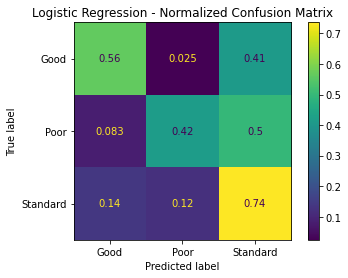

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_val, logistic_pred, normalize="true")
plt.title("Logistic Regression - Normalized Confusion Matrix")
plt.show()

In [37]:
# Create a Results Table
results = []

results.append({
    "Model": "Dummy",
    "Accuracy": accuracy_score(y_val, dummy_pred),
    "Macro_Precision": precision_score(y_val, dummy_pred, average="macro", zero_division=0),
    "Macro_Recall": recall_score(y_val, dummy_pred, average="macro", zero_division=0),
    "Macro_F1": f1_score(y_val, dummy_pred, average="macro", zero_division=0)
})

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, logistic_pred),
    "Macro_Precision": precision_score(y_val, logistic_pred, average="macro", zero_division=0),
    "Macro_Recall": recall_score(y_val, logistic_pred, average="macro", zero_division=0),
    "Macro_F1": f1_score(y_val, logistic_pred, average="macro", zero_division=0)
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Dummy,0.5336,0.177867,0.333333,0.231960
1,Logistic Regression,0.6138,0.593289,0.572618,0.574272


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, logistic_pred, labels=["Good", "Poor", "Standard"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual Good", "Actual Poor", "Actual Standard"],
    columns=["Predicted Good", "Predicted Poor", "Predicted Standard"]
)

cm_df

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,1517,66,1105
Actual Poor,359,1798,2151
Actual Standard,1118,994,5892


In [39]:
cm_normalized = confusion_matrix(y_val, logistic_pred,
    labels=["Good", "Poor", "Standard"],
    normalize="true"
)

cm_normalized_df = pd.DataFrame(
    cm_normalized.round(3),
    index=["Actual Good", "Actual Poor", "Actual Standard"],
    columns=["Predicted Good", "Predicted Poor", "Predicted Standard"]
)

cm_normalized_df

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,0.564,0.025,0.411
Actual Poor,0.083,0.417,0.499
Actual Standard,0.140,0.124,0.736


## 4) Model Evaluation

In [40]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a multiclass classification model.
    """

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

    print(f"\n{model_name}")
    print("=" * 50)

    for metric, value in metrics.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics

In [41]:
logistic_results = evaluate_model("Logistic Regression", y_val, logistic_pred)


Logistic Regression
Accuracy: 0.6138
Macro_Precision: 0.5933
Macro_Recall: 0.5726
Macro_F1: 0.5743

Classification Report:
              precision    recall  f1-score   support

        Good       0.51      0.56      0.53      2688
        Poor       0.63      0.42      0.50      4308
    Standard       0.64      0.74      0.69      8004

    accuracy                           0.61     15000
   macro avg       0.59      0.57      0.57     15000
weighted avg       0.62      0.61      0.61     15000



#### XGBoost

In [42]:
import xgboost as xgb

print(xgb.__version__)

C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


1.5.0


In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [44]:
xgb_model.fit(X_train_processed, y_train)

C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, eval_metric='mlogloss', gamma=0,
              gpu_id=-1, importance_type=None, interaction_constraints='',
              learning_rate=0.05, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=-1, num_class=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=None, subsample=0.8,
              tree_method='exact', validate_parameters=1, ...)

In [45]:
xgb_pred = xgb_model.predict(X_val_processed)

In [46]:
xgb_results = evaluate_model("XGBoost", y_val, xgb_pred)


XGBoost
Accuracy: 0.6909
Macro_Precision: 0.6680
Macro_Recall: 0.6677
Macro_F1: 0.6673

Classification Report:
              precision    recall  f1-score   support

        Good       0.58      0.61      0.60      2688
        Poor       0.70      0.65      0.67      4308
    Standard       0.73      0.74      0.73      8004

    accuracy                           0.69     15000
   macro avg       0.67      0.67      0.67     15000
weighted avg       0.69      0.69      0.69     15000



In [47]:
results_df = pd.DataFrame([
    {
        "Model": "Dummy",
        "Accuracy": accuracy_score(y_val, dummy_pred),
        "Macro_Precision": precision_score(y_val, dummy_pred, average="macro", zero_division=0),
        "Macro_Recall": recall_score(y_val, dummy_pred, average="macro", zero_division=0),
        "Macro_F1": f1_score(y_val, dummy_pred, average="macro", zero_division=0)
    },
    logistic_results,
    xgb_results
])

results_df

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Dummy,0.533600,0.177867,0.333333,0.231960
1,Logistic Regression,0.613800,0.593289,0.572618,0.574272
2,XGBoost,0.690867,0.668039,0.667706,0.667350


In [48]:
print(classification_report( y_val, xgb_pred, zero_division=0))

              precision    recall  f1-score   support

        Good       0.58      0.61      0.60      2688
        Poor       0.70      0.65      0.67      4308
    Standard       0.73      0.74      0.73      8004

    accuracy                           0.69     15000
   macro avg       0.67      0.67      0.67     15000
weighted avg       0.69      0.69      0.69     15000



In [49]:
xgb_cm = confusion_matrix(y_val, xgb_pred, labels=["Good", "Poor", "Standard"], normalize="true")

pd.DataFrame(
    xgb_cm.round(3),
    index=[
        "Actual Good",
        "Actual Poor",
        "Actual Standard"
    ],
    columns=[
        "Predicted Good",
        "Predicted Poor",
        "Predicted Standard"
    ]
)

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,0.614,0.026,0.359
Actual Poor,0.055,0.651,0.294
Actual Standard,0.121,0.140,0.738


In [50]:
# Determine top 20 XGBoost features
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 61


In [51]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
50,categorical__Credit_Mix_Good,0.173001
51,categorical__Credit_Mix_Standard,0.160272
49,categorical__Credit_Mix_Bad,0.099745
54,categorical__Payment_of_Min_Amount_Yes,0.095796
53,categorical__Payment_of_Min_Amount_No,0.068067
11,numeric__Outstanding_Debt,0.035208
5,numeric__Interest_Rate,0.031042
4,numeric__Num_Credit_Card,0.019557
7,numeric__Delay_from_due_date,0.014317
28,categorical__Month_February,0.014246


In [52]:
# Inspect prediction Probabilities
xgb_probabilities = xgb_model.predict_proba(X_val_processed)

xgb_probabilities[:5]

array([[0.01055915, 0.04088293, 0.9485579 ],
       [0.0237902 , 0.03909234, 0.93711746],
       [0.01343118, 0.04111639, 0.94545245],
       [0.04085705, 0.08234694, 0.876796  ],
       [0.05087127, 0.07300416, 0.87612456]], dtype=float32)

In [53]:
print(xgb_model.classes_)

['Good' 'Poor' 'Standard']


In [54]:
# Check the model confidence
prediction_confidence = xgb_probabilities.max(axis=1)

print(pd.Series(prediction_confidence).describe())

count    15000.000000
mean         0.707120
std          0.154793
min          0.337077
25%          0.567252
50%          0.740454
75%          0.828431
max          0.980607
dtype: float64


In [55]:
confidence_df = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": xgb_pred,
    "Confidence": prediction_confidence
})

confidence_df.groupby("Predicted")["Confidence"].describe()

,count,mean,std,min,25%,50%,75%,max
Predicted,,,,,,,,
Good,2860.0,0.590982,0.134297,0.340805,0.490051,0.552484,0.670102,0.922150
Poor,3998.0,0.719721,0.110571,0.337077,0.664080,0.752923,0.801343,0.926198
Standard,8142.0,0.741728,0.160607,0.345781,0.600330,0.787912,0.860394,0.980607


In [56]:
pd.crosstab(
    train_df["Credit_Mix"],
    train_df["Credit_Score"],
    normalize="index"
).round(3)

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,0.014,0.600,0.387
Good,0.486,0.163,0.351
Standard,0.055,0.213,0.732


In [57]:
pd.crosstab(
    train_df["Payment_of_Min_Amount"],
    train_df["Credit_Score"],
    normalize="index"
).round(3)

Credit_Score,Good,Poor,Standard
Payment_of_Min_Amount,,,
NM,0.190,0.292,0.518
No,0.381,0.136,0.483
Yes,0.036,0.396,0.568


#### Model B — Without Credit_Mix

In [58]:
CATEGORICAL_FEATURES_NO_CREDIT_MIX = [
    "Month",
    "Occupation",
    "Payment_of_Min_Amount",
    "Payment_Behaviour",
]

In [59]:
categorical_pipeline_no_credit_mix = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ]
)

In [60]:
preprocessor_no_credit_mix = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline_no_credit_mix, CATEGORICAL_FEATURES_NO_CREDIT_MIX)
    ]
)

In [61]:
X_train_no_cm = preprocessor_no_credit_mix.fit_transform(X_train)

X_val_no_cm = preprocessor_no_credit_mix.transform(X_val)

X_test_no_cm = preprocessor_no_credit_mix.transform(X_test)

In [62]:
print(X_train_no_cm.shape)
print(X_val_no_cm.shape)
print(X_test_no_cm.shape)

(70000, 58)
(15000, 58)
(15000, 58)


In [63]:
xgb_no_credit_mix = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [64]:
xgb_no_credit_mix.fit(X_train_no_cm, y_train)

C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8,
              enable_categorical=False, eval_metric='mlogloss', gamma=0,
              gpu_id=-1, importance_type=None, interaction_constraints='',
              learning_rate=0.05, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=-1, num_class=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=None, subsample=0.8,
              tree_method='exact', validate_parameters=1, ...)

In [65]:
xgb_no_cm_pred = xgb_no_credit_mix.predict( X_val_no_cm)

In [66]:
xgb_no_cm_results = evaluate_model(
    "XGBoost - Without Credit Mix",
    y_val,
    xgb_no_cm_pred
)


XGBoost - Without Credit Mix
Accuracy: 0.6816
Macro_Precision: 0.6609
Macro_Recall: 0.6424
Macro_F1: 0.6506

Classification Report:
              precision    recall  f1-score   support

        Good       0.57      0.53      0.55      2688
        Poor       0.71      0.65      0.68      4308
    Standard       0.70      0.75      0.73      8004

    accuracy                           0.68     15000
   macro avg       0.66      0.64      0.65     15000
weighted avg       0.68      0.68      0.68     15000



In [67]:
comparison = pd.DataFrame([
    xgb_results,
    xgb_no_cm_results
])

comparison

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,XGBoost,0.690867,0.668039,0.667706,0.667350
1,XGBoost - Without Credit Mix,0.681600,0.660860,0.642446,0.650572


### Model Optimization

In [68]:
import sklearn

print(sklearn.__version__)

from sklearn.model_selection import StratifiedGroupKFold

print("StratifiedGroupKFold is available.")

1.1.3
StratifiedGroupKFold is available.


In [69]:
groups = train_df["Customer_ID"]

In [70]:
print(len(X_train))
print(len(y_train))
print(len(groups))

70000
70000
70000


In [71]:
#Create the grouped CV splitter
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [72]:
from xgboost import XGBClassifier

xgb_tuning_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [73]:
param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.03, 0.05, 0.08, 0.10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

In [74]:
# Set up RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [75]:
random_search.fit(X_train_processed, y_train, groups=groups)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


RandomizedSearchCV(cv=StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss', gamma=None,
                                           gpu_id=None, importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=None,
                                           max_de...
                                           validate_parameters=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.03, 0.05, 0.08,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='f1_macro',
                   verbose=2)

In [76]:
dir(random_search)

['__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_check_feature_names',
 '_check_n_features',
 '_check_refit_for_multimetric',
 '_estimator_type',
 '_format_results',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_required_parameters',
 '_run_search',
 '_select_best_index',
 '_validate_data',
 'best_estimator_',
 'best_index_',
 'best_params_',
 'best_score_',
 'classes_',
 'cv',
 'cv_results_',
 'decision_function',
 'error_score',
 'estimator',
 'fit',
 'get_params',
 'inverse_transform',
 'multimetric_',
 'n_features_in_',
 'n_iter

In [77]:
print('Best Parameters:')
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [78]:
print('Best Score ', random_search.best_score_)

Best Score  0.6709361404218355


In [79]:
best_xgb = random_search.best_estimator_

In [80]:
tuned_xgb_pred = best_xgb.predict(X_val_processed)

In [81]:
tuned_xgb_results = evaluate_model("Tuned XGBoost", y_val, tuned_xgb_pred)


Tuned XGBoost
Accuracy: 0.6933
Macro_Precision: 0.6709
Macro_Recall: 0.6716
Macro_F1: 0.6706

Classification Report:
              precision    recall  f1-score   support

        Good       0.58      0.62      0.60      2688
        Poor       0.70      0.65      0.68      4308
    Standard       0.73      0.74      0.73      8004

    accuracy                           0.69     15000
   macro avg       0.67      0.67      0.67     15000
weighted avg       0.69      0.69      0.69     15000



In [82]:
final_comparison = pd.DataFrame([xgb_results, tuned_xgb_results])

final_comparison

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,XGBoost,0.690867,0.668039,0.667706,0.667350
1,Tuned XGBoost,0.693333,0.670851,0.671624,0.670592


In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_val, tuned_xgb_pred, zero_division=0))

              precision    recall  f1-score   support

        Good       0.58      0.62      0.60      2688
        Poor       0.70      0.65      0.68      4308
    Standard       0.73      0.74      0.73      8004

    accuracy                           0.69     15000
   macro avg       0.67      0.67      0.67     15000
weighted avg       0.69      0.69      0.69     15000



In [84]:
tuned_cm = confusion_matrix(
    y_val,
    tuned_xgb_pred,
    labels=["Good", "Poor", "Standard"],
    normalize="true"
)

pd.DataFrame(
    tuned_cm.round(3),
    index=[
        "Actual Good",
        "Actual Poor",
        "Actual Standard"
    ],
    columns=[
        "Predicted Good",
        "Predicted Poor",
        "Predicted Standard"
    ]
)

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,0.625,0.024,0.352
Actual Poor,0.056,0.651,0.293
Actual Standard,0.122,0.139,0.739


#### Investigate Class Imbalance

In [85]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

class_weight_dict

{'Good': 1.8705574261129816,
 'Poor': 1.1492554466499203,
 'Standard': 0.6268525732298131}

In [86]:
sample_weights = y_train.map(class_weight_dict).values

In [87]:
pd.Series(sample_weights).describe()

count    70000.000000
mean         1.000000
std          0.464282
min          0.626853
25%          0.626853
50%          0.626853
75%          1.149255
max          1.870557
dtype: float64

In [88]:
weighted_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    subsample=0.9,
    n_estimators=200,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.03,
    gamma=0.1,
    colsample_bytree=0.9
)

In [89]:
weighted_xgb.fit(X_train_processed, y_train, sample_weight=sample_weights)

C:\Users\Lum-neh Angela\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.9,
              enable_categorical=False, eval_metric='mlogloss', gamma=0.1,
              gpu_id=-1, importance_type=None, interaction_constraints='',
              learning_rate=0.03, max_delta_step=0, max_depth=8,
              min_child_weight=3, missing=nan, monotone_constraints='()',
              n_estimators=200, n_jobs=-1, num_class=3, num_parallel_tree=1,
              objective='multi:softprob', predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=None, subsample=0.9,
              tree_method='exact', validate_parameters=1, ...)

In [90]:
weighted_pred = weighted_xgb.predict(X_val_processed)

In [91]:
weighted_results = evaluate_model("Weighted XGBoost", y_val, weighted_pred)


Weighted XGBoost
Accuracy: 0.6781
Macro_Precision: 0.6622
Macro_Recall: 0.7191
Macro_F1: 0.6725

Classification Report:
              precision    recall  f1-score   support

        Good       0.51      0.82      0.63      2688
        Poor       0.65      0.75      0.70      4308
    Standard       0.82      0.60      0.69      8004

    accuracy                           0.68     15000
   macro avg       0.66      0.72      0.67     15000
weighted avg       0.72      0.68      0.68     15000



In [92]:
weighted_cm = confusion_matrix(
    y_val,
    weighted_pred,
    labels=["Good", "Poor", "Standard"],
    normalize="true"
)

weighted_cm_df = pd.DataFrame(
    weighted_cm.round(3),
    index=[
        "Actual Good",
        "Actual Poor",
        "Actual Standard"
    ],
    columns=[
        "Predicted Good",
        "Predicted Poor",
        "Predicted Standard"
    ]
)

weighted_cm_df

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,0.816,0.027,0.157
Actual Poor,0.104,0.746,0.149
Actual Standard,0.202,0.203,0.595


#### Final Test Evaluation

In [93]:
# Model 1: Tuned XGBoost
tuned_test_pred = best_xgb.predict(X_test_processed)

In [94]:
tuned_test_results = evaluate_model("Tuned XGBoost - Test", y_test, tuned_test_pred)


Tuned XGBoost - Test
Accuracy: 0.7079
Macro_Precision: 0.6851
Macro_Recall: 0.6867
Macro_F1: 0.6858

Classification Report:
              precision    recall  f1-score   support

        Good       0.60      0.62      0.61      2666
        Poor       0.72      0.70      0.71      4387
    Standard       0.74      0.74      0.74      7947

    accuracy                           0.71     15000
   macro avg       0.69      0.69      0.69     15000
weighted avg       0.71      0.71      0.71     15000



In [95]:
# Model 2: Weighted XGBoost
weighted_test_pred = weighted_xgb.predict(X_test_processed)

In [96]:
weighted_test_results = evaluate_model("Weighted XGBoost - Test", y_test, weighted_test_pred)


Weighted XGBoost - Test
Accuracy: 0.6821
Macro_Precision: 0.6662
Macro_Recall: 0.7221
Macro_F1: 0.6757

Classification Report:
              precision    recall  f1-score   support

        Good       0.52      0.80      0.63      2666
        Poor       0.66      0.77      0.71      4387
    Standard       0.83      0.59      0.69      7947

    accuracy                           0.68     15000
   macro avg       0.67      0.72      0.68     15000
weighted avg       0.72      0.68      0.68     15000



In [97]:
test_comparison = pd.DataFrame([tuned_test_results, weighted_test_results])

test_comparison

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1
0,Tuned XGBoost - Test,0.707933,0.685138,0.686732,0.685793
1,Weighted XGBoost - Test,0.682067,0.666236,0.722062,0.675663


In [98]:
weighted_test_cm = confusion_matrix(
    y_test,
    weighted_test_pred,
    labels=["Good", "Poor", "Standard"],
    normalize="true"
)

pd.DataFrame(
    weighted_test_cm.round(3),
    index=[
        "Actual Good",
        "Actual Poor",
        "Actual Standard"
    ],
    columns=[
        "Predicted Good",
        "Predicted Poor",
        "Predicted Standard"
    ]
)

,Predicted Good,Predicted Poor,Predicted Standard
Actual Good,0.805,0.038,0.158
Actual Poor,0.104,0.768,0.128
Actual Standard,0.196,0.211,0.593


## Save Final Model, Preprocessor, Evaluation Data & Monitoring Reference

In [99]:
# Save production model artifacts
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.pkl")
joblib.dump(best_xgb, MODELS_DIR / "xgboost_credit_score.pkl")

# Save processed datasets and labels
joblib.dump(X_train_processed, PROCESSED_DIR / "X_train_processed.pkl")
joblib.dump(X_val_processed, PROCESSED_DIR / "X_val_processed.pkl")
joblib.dump(X_test_processed, PROCESSED_DIR / "X_test_processed.pkl")

joblib.dump(y_train, PROCESSED_DIR / "y_train.pkl")
joblib.dump(y_val, PROCESSED_DIR / "y_val.pkl")
joblib.dump(y_test, PROCESSED_DIR / "y_test.pkl")

# Save feature metadata
joblib.dump(feature_names, PROCESSED_DIR / "feature_names.pkl")

# Save raw/cleaned split datasets
train_df.to_pickle(PROCESSED_DIR / "train_df.pkl")
val_df.to_pickle(PROCESSED_DIR / "val_df.pkl")
test_df.to_pickle(PROCESSED_DIR / "test_df.pkl")

# Save test customer IDs
joblib.dump(test_df["Customer_ID"], PROCESSED_DIR / "test_customer_ids.pkl")

# Save the exact training population as the monitoring reference.
# This is the 70,000-row customer-level training split.
train_df.to_pickle(PROCESSED_DIR / "monitoring_reference.pkl")

print("All model and monitoring artifacts saved successfully.")


All model and monitoring artifacts saved successfully.


In [100]:
# Verify saved artifacts
expected_artifacts = [
    MODELS_DIR / "preprocessor.pkl",
    MODELS_DIR / "xgboost_credit_score.pkl",
    PROCESSED_DIR / "X_train_processed.pkl",
    PROCESSED_DIR / "X_val_processed.pkl",
    PROCESSED_DIR / "X_test_processed.pkl",
    PROCESSED_DIR / "y_train.pkl",
    PROCESSED_DIR / "y_val.pkl",
    PROCESSED_DIR / "y_test.pkl",
    PROCESSED_DIR / "feature_names.pkl",
    PROCESSED_DIR / "test_customer_ids.pkl",
    PROCESSED_DIR / "train_df.pkl",
    PROCESSED_DIR / "val_df.pkl",
    PROCESSED_DIR / "test_df.pkl",
    PROCESSED_DIR / "monitoring_reference.pkl",
]

for artifact in expected_artifacts:
    print(f"{'OK' if artifact.exists() else 'MISSING'}: {artifact}")


OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\models\preprocessor.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\models\xgboost_credit_score.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\X_train_processed.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\X_val_processed.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\X_test_processed.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\y_train.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\y_val.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\y_test.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\feature_names.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\test_customer_ids.pkl
OK: C:\Users\Lum-neh Angela\Documents\Data\Credi